# matthew ece405c constructing the LiH Qubit Hamiltonian

In [2]:
from qiskit_nature.units import DistanceUnit # to make angstroms clear
from qiskit_nature.second_q.drivers import PySCFDriver # elec structure from molecular geometry
from qiskit_nature.second_q.mappers import JordanWignerMapper # fermionic -> qubit mapping

In [5]:
bond_length = 1.6  # Angstrom

driver = PySCFDriver(
    atom=f"Li 0 0 0; H 0 0 {bond_length}", # atom with the co-ords
    basis="sto3g", # the basis set, STO just means slater type orbital and 3G means we approximate with 3 gaussian functions
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)

In [7]:
problem = driver.run() # returning a ElectronicStructureProblem object. 
print(problem)

In [9]:
fermionic_hamiltonian = problem.hamiltonian.second_q_op()

print("Number of spin orbitals:", problem.num_spin_orbitals)
print("Number of particles:", problem.num_particles)

Number of spin orbitals: 12
Number of particles: (2, 2)


In [10]:
print("Some fermionic Hamiltonian terms:\n")

for i, (label, coeff) in enumerate(fermionic_hamiltonian.items()):
    print(f"{coeff.real:+.8f} * '{label}'")
    if i >= 14:
        break

Some fermionic Hamiltonian terms:

-4.72739313 * '+_0 -_0'
+0.10549968 * '+_0 -_1'
+0.16696141 * '+_0 -_2'
-0.03467720 * '+_0 -_5'
+0.10549968 * '+_1 -_0'
-1.49264622 * '+_1 -_1'
+0.03289283 * '+_1 -_2'
-0.05270788 * '+_1 -_5'
+0.16696141 * '+_2 -_0'
+0.03289283 * '+_2 -_1'
-1.12554474 * '+_2 -_2'
+0.03044557 * '+_2 -_5'
-1.13579985 * '+_3 -_3'
-1.13579985 * '+_4 -_4'
-0.03467720 * '+_5 -_0'


In [11]:
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(fermionic_hamiltonian)

print(qubit_hamiltonian)

SparsePauliOp(['IIIIIIIIIIII', 'IIIIIIIIIIIZ', 'IIIIIIIIIIYY', 'IIIIIIIIIIXX', 'IIIIIIIIIYZY', 'IIIIIIIIIXZX', 'IIIIIIYZZZZY', 'IIIIIIXZZZZX', 'IIIIIIIIIIZI', 'IIIIIIIIIYYI', 'IIIIIIIIIXXI', 'IIIIIIYZZZYI', 'IIIIIIXZZZXI', 'IIIIIIIIIZII', 'IIIIIIYZZYII', 'IIIIIIXZZXII', 'IIIIIIIIZIII', 'IIIIIIIZIIII', 'IIIIIIZIIIII', 'IIIIIZIIIIII', 'IIIIYYIIIIII', 'IIIIXXIIIIII', 'IIIYZYIIIIII', 'IIIXZXIIIIII', 'YZZZZYIIIIII', 'XZZZZXIIIIII', 'IIIIZIIIIIII', 'IIIYYIIIIIII', 'IIIXXIIIIIII', 'YZZZYIIIIIII', 'XZZZXIIIIIII', 'IIIZIIIIIIII', 'YZZYIIIIIIII', 'XZZXIIIIIIII', 'IIZIIIIIIIII', 'IZIIIIIIIIII', 'ZIIIIIIIIIII', 'IIIIIIIIIIZZ', 'IIIIIIIIIYYZ', 'IIIIIIIIIXXZ', 'IIIIIIYZZZYZ', 'IIIIIIXZZZXZ', 'IIIIIIIIIZIZ', 'IIIIIIYZZYIZ', 'IIIIIIXZZXIZ', 'IIIIIIIIZIIZ', 'IIIIIIIZIIIZ', 'IIIIIIZIIIIZ', 'IIIIIZIIIIIZ', 'IIIIYYIIIIIZ', 'IIIIXXIIIIIZ', 'IIIYZYIIIIIZ', 'IIIXZXIIIIIZ', 'YZZZZYIIIIIZ', 'XZZZZXIIIIIZ', 'IIIIZIIIIIIZ', 'IIIYYIIIIIIZ', 'IIIXXIIIIIIZ', 'YZZZYIIIIIIZ', 'XZZZXIIIIIIZ', 'IIIZIIIIIIIZ', 'YZZYIIII

In [12]:
print("Some qubit Hamiltonian terms:\n")

for i, (pauli, coeff) in enumerate(qubit_hamiltonian.to_list()):
    print(f"{coeff.real:+.8f} * {pauli}")
    if i >= 24:
        break

Some qubit Hamiltonian terms:

-5.12807445 * IIIIIIIIIIII
+1.00649888 * IIIIIIIIIIIZ
+0.01431929 * IIIIIIIIIIYY
+0.01431929 * IIIIIIIIIIXX
+0.02534773 * IIIIIIIIIYZY
+0.02534773 * IIIIIIIIIXZX
-0.00166630 * IIIIIIYZZZZY
-0.00166630 * IIIIIIXZZZZX
-0.11846054 * IIIIIIIIIIZI
-0.00747751 * IIIIIIIIIYYI
-0.00747751 * IIIIIIIIIXXI
+0.00530923 * IIIIIIYZZZYI
+0.00530923 * IIIIIIXZZZXI
-0.19809730 * IIIIIIIIIZII
+0.01468666 * IIIIIIYZZYII
+0.01468666 * IIIIIIXZZXII
-0.23046823 * IIIIIIIIZIII
-0.23046823 * IIIIIIIZIIII
-0.38500533 * IIIIIIZIIIII
+1.00649888 * IIIIIZIIIIII
+0.01431929 * IIIIYYIIIIII
+0.01431929 * IIIIXXIIIIII
+0.02534773 * IIIYZYIIIIII
+0.02534773 * IIIXZXIIIIII
-0.00166630 * YZZZZYIIIIII


In [13]:
print("Qubit count:", qubit_hamiltonian.num_qubits)
print("Number of Pauli terms:", len(qubit_hamiltonian))

Qubit count: 12
Number of Pauli terms: 631


In [15]:
for i, (pauli, coeff) in enumerate(qubit_hamiltonian_simplified.to_list()):
    print(f"c_{i} = {coeff.real:+.8f},   P_{i} = {pauli}")
    if i >= 14:
        break

c_0 = -5.12807445,   P_0 = IIIIIIIIIIII
c_1 = +1.00649888,   P_1 = IIIIIIIIIIIZ
c_2 = +0.01431929,   P_2 = IIIIIIIIIIYY
c_3 = +0.01431929,   P_3 = IIIIIIIIIIXX
c_4 = +0.02534773,   P_4 = IIIIIIIIIYZY
c_5 = +0.02534773,   P_5 = IIIIIIIIIXZX
c_6 = -0.00166630,   P_6 = IIIIIIYZZZZY
c_7 = -0.00166630,   P_7 = IIIIIIXZZZZX
c_8 = -0.11846054,   P_8 = IIIIIIIIIIZI
c_9 = -0.00747751,   P_9 = IIIIIIIIIYYI
c_10 = -0.00747751,   P_10 = IIIIIIIIIXXI
c_11 = +0.00530923,   P_11 = IIIIIIYZZZYI
c_12 = +0.00530923,   P_12 = IIIIIIXZZZXI
c_13 = -0.19809730,   P_13 = IIIIIIIIIZII
c_14 = +0.01468666,   P_14 = IIIIIIYZZYII


In [16]:
print("=== LiH Qubit Hamiltonian Summary ===")
print(f"Bond length: {bond_length} Angstrom")
print(f"Spin orbitals: {problem.num_spin_orbitals}")
print(f"Particles (alpha, beta): {problem.num_particles}")
print(f"Mapped qubits: {qubit_hamiltonian.num_qubits}")
print(f"Pauli terms: {len(qubit_hamiltonian_simplified)}")

=== LiH Qubit Hamiltonian Summary ===
Bond length: 1.6 Angstrom
Spin orbitals: 12
Particles (alpha, beta): (2, 2)
Mapped qubits: 12
Pauli terms: 631


# VQE time

In [33]:
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import NumPyMinimumEigensolver, VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import n_local

In [34]:
exact_solver = NumPyMinimumEigensolver()
exact_result = exact_solver.compute_minimum_eigenvalue(qubit_hamiltonian_simplified)

print("Exact minimum eigenvalue (qubit Hamiltonian):")
print(exact_result.eigenvalue.real)

Exact minimum eigenvalue (qubit Hamiltonian):
-8.87453164935851


In [35]:
ansatz = n_local(
    num_qubits=qubit_hamiltonian.num_qubits,
    rotation_blocks=["ry", "rz"],
    entanglement_blocks="cx",
    entanglement="linear",
    reps=4,
)

print("Ansatz qubits:", ansatz.num_qubits)
print("Ansatz parameters:", ansatz.num_parameters)
print("Ansatz depth:", ansatz.decompose().depth())

Ansatz qubits: 12
Ansatz parameters: 120
Ansatz depth: 27


In [36]:
import matplotlib.pyplot as plt

fig = ansatz.decompose().draw(output="mpl", fold=50)
fig.savefig("lih_ansatz_circuit.png", dpi=300, bbox_inches="tight")
plt.show()

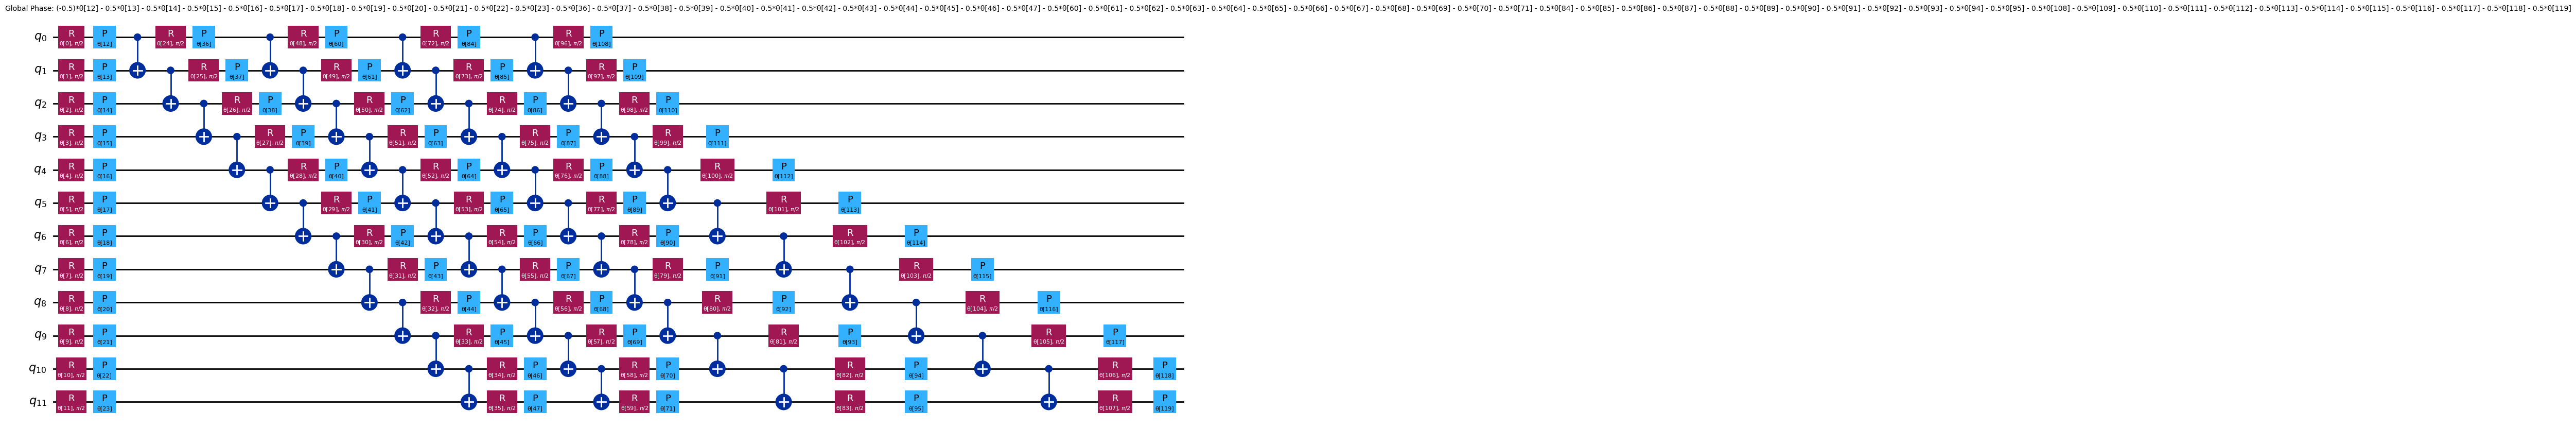

In [37]:
fig

In [42]:
vqe_energies = []
vqe_counts = []

def store_intermediate_result(eval_count, parameters, mean, metadata):
    vqe_counts.append(eval_count)
    vqe_energies.append(mean)

In [43]:
estimator = StatevectorEstimator()
optimizer = COBYLA(maxiter=200)

vqe_solver = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=store_intermediate_result,
)

vqe_result = vqe_solver.compute_minimum_eigenvalue(qubit_hamiltonian_simplified)

print("VQE minimum eigenvalue:")
print(vqe_result.eigenvalue.real)

VQE minimum eigenvalue:
-6.794506438420569


In [44]:
exact_energy = exact_result.eigenvalue.real
vqe_energy = vqe_result.eigenvalue.real
abs_error = abs(vqe_energy - exact_energy)

print("=== Energy Comparison ===")
print(f"Exact energy: {exact_energy:.10f}")
print(f"VQE energy:   {vqe_energy:.10f}")
print(f"Abs. error:   {abs_error:.10e}")

=== Energy Comparison ===
Exact energy: -8.8745316494
VQE energy:   -6.7945064384
Abs. error:   2.0800252109e+00


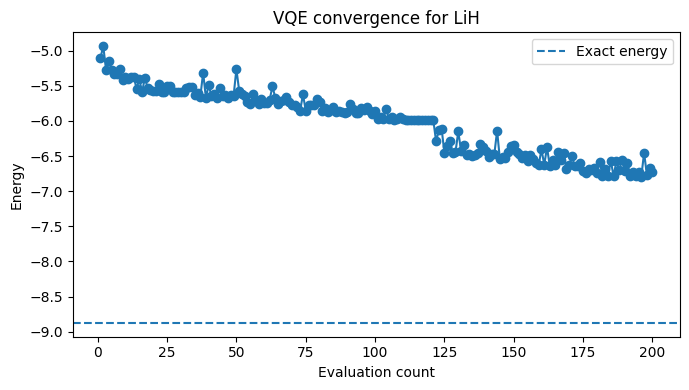

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(vqe_counts, vqe_energies, marker="o")
plt.axhline(exact_energy, linestyle="--", label="Exact energy")
plt.xlabel("Evaluation count")
plt.ylabel("Energy")
plt.title("VQE convergence for LiH")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
print("Optimal parameters found by VQE:")
print(vqe_result.optimal_point)

Optimal parameters found by VQE:
[-1.93772393 -4.66618392 -5.77912503  4.64538263  3.45445413 -1.71909209
 -5.33055822  4.38634757  6.39910283  6.08767927 -4.5421946  -2.88595114
  6.32557552 -0.12935566  5.69004866  5.87696889  1.32276547 -2.90744941
 -0.48495858  3.19910121 -1.37257659  3.86519925 -6.53603531 -3.38098126
 -4.24026865 -3.92675132  0.89122578  1.7463468  -4.63139212 -4.98281927
  4.41567899  4.95178099 -4.00234666 -2.48421471 -4.07775617 -5.14850765
 -0.83823675 -6.53344128 -2.30971917 -3.53788206  2.42390171  1.28602765
  0.98589493  2.74073989 -3.65174367 -5.73936851 -1.16129223 -5.27579228
 -3.10239331  1.67498764 -2.04079774 -4.98966049 -6.18290035  2.37638729
  0.21902411  2.81665219 -0.49571075 -6.06327492 -4.97039136 -1.53813678
  2.7537645   0.39009435 -5.41373137  7.57465716  3.30136975 -2.66991035
  7.1215774   1.64470162  4.8091406  -2.1264667  -5.10907651  5.020971  ]


In [31]:
print("=== LiH VQE Summary ===")
print(f"Bond length (Angstrom): {bond_length}")
print(f"Qubits: {qubit_hamiltonian.num_qubits}")
print(f"Pauli terms: {len(qubit_hamiltonian_simplified)}")
print(f"Ansatz parameters: {ansatz.num_parameters}")
print(f"Ansatz depth: {ansatz.decompose().depth()}")
print(f"Exact energy: {exact_energy:.10f}")
print(f"VQE energy:   {vqe_energy:.10f}")
print(f"Absolute error: {abs_error:.10e}")

=== LiH VQE Summary ===
Bond length (Angstrom): 1.6
Qubits: 12
Pauli terms: 631
Ansatz parameters: 72
Ansatz depth: 19
Exact energy: -8.8745316494
VQE energy:   -8.0560437610
Absolute error: 8.1848788840e-01


In [46]:
for reps in [1, 2, 3]:
    ansatz = n_local(
        num_qubits=qubit_hamiltonian.num_qubits,
        rotation_blocks=["ry", "rz"],
        entanglement_blocks="cx",
        entanglement="linear",
        reps=reps,
    )
    print(f"reps={reps}")
    print("  parameters:", ansatz.num_parameters)
    print("  depth:", ansatz.decompose().depth())

reps=1
  parameters: 48
  depth: 15
reps=2
  parameters: 72
  depth: 19
reps=3
  parameters: 96
  depth: 23


### theres a clear tradeoff between making the ansatz more expressive and increasing dimensionality and complexity of the loss function. 